In [705]:
import pandas as pd


df=pd.read_csv("floodsense_training_data.csv")

In [706]:
df.head()

,date,elevation,evaporation,latitude,longitude,precipitation,pressure,soil_moisture,temperature,water_area_km2,...,soil_3day_avg,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,ds_idx,flood_event,district
0,8/21/2024,275.0,-0.002420,34.02,71.98,NaN,99056.47984,0.278052,30.120004,651.439640,...,0.305728,234.0,8,2024,1,-139.274059,-0.176137,1.0,0,KP_District
1,9/17/2022,109.0,-0.002011,26.25,68.00,0.001034,98899.29858,0.127672,28.925564,316.305625,...,0.135051,260.0,9,2022,1,-306.647003,-0.492248,2.0,0,Sindh_District
2,4/17/2024,275.0,-0.000326,34.02,71.98,0.064778,99683.73637,0.094294,28.598953,334.627838,...,0.098971,108.0,4,2024,0,334.243792,870.321111,9.0,0,KP_District
3,12/1/2023,58.0,-0.000102,29.50,68.00,0.000000,100519.08430,0.086342,20.705847,414.324261,...,0.086896,335.0,12,2023,0,-161.600291,-0.280593,6.0,0,Balochistan_District
4,5/26/2024,275.0,-0.000207,34.02,71.98,0.000000,98604.29262,0.080985,39.160096,999.808113,...,0.081202,147.0,5,2024,0,-180.576874,-0.152981,0.0,1,KP_District


In [707]:
print(df.duplicated().sum())

67


In [708]:
df=df.drop_duplicates()
print(df.duplicated().sum())

0


In [709]:
print(df.shape)
df=df.drop(columns=['elevation', 'latitude', 'longitude'])
print(df.shape)

(1367, 25)
(1367, 22)


In [710]:
df.isnull().sum()

,0
date,0
evaporation,2
precipitation,206
pressure,2
soil_moisture,1
temperature,1
water_area_km2,2
wind_speed,2
humidity,1
precip_3day_avg,2


In [711]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1367 entries, 0 to 1433
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1367 non-null   object 
 1   evaporation            1365 non-null   float64
 2   precipitation          1161 non-null   float64
 3   pressure               1365 non-null   float64
 4   soil_moisture          1366 non-null   float64
 5   temperature            1366 non-null   float64
 6   water_area_km2         1365 non-null   float64
 7   wind_speed             1365 non-null   float64
 8   humidity               1366 non-null   float64
 9   precip_3day_avg        1365 non-null   float64
 10  precip_7day_avg        1365 non-null   float64
 11  temp_3day_avg          1365 non-null   float64
 12  soil_3day_avg          1365 non-null   float64
 13  day_of_year            1365 non-null   float64
 14  month                  1367 non-null   int64  
 15  year     

In [712]:
import numpy as np
# Dono +inf aur -inf count ho jayenge
count = np.isinf(df['water_area_pct_change']).sum()
print(count)

1


In [713]:
import numpy as np

inf_water_area_pct_change_rows = df[np.isinf(df['water_area_pct_change'])]
display(inf_water_area_pct_change_rows)

print(f"Number of rows with infinite 'water_area_pct_change': {len(inf_water_area_pct_change_rows)}")

,date,evaporation,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,...,soil_3day_avg,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,ds_idx,flood_event,district
692,1/2/2022,-0.000335,0.004603,100752.3197,0.114194,15.426994,659.515597,3.202759,56.801856,0.010582,...,0.117622,2.0,1,2022,0,659.515597,inf,0.0,0,Sindh_District


Number of rows with infinite 'water_area_pct_change': 1


In [714]:
import numpy as np

# Sirf numerical columns select karke unmein inf values ka sum nikalna
inf_counts = df.select_dtypes(include=[np.number]).apply(lambda x: np.isinf(x).sum())

# Sirf wo columns dikhaye jin mein kam az kam ek inf value ho
print(inf_counts[inf_counts > 0])

water_area_pct_change    1
dtype: int64


In [715]:
df['water_area_pct_change'] = df['water_area_pct_change'].clip(upper=1000)

In [716]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1367 entries, 0 to 1433
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1367 non-null   object 
 1   evaporation            1365 non-null   float64
 2   precipitation          1161 non-null   float64
 3   pressure               1365 non-null   float64
 4   soil_moisture          1366 non-null   float64
 5   temperature            1366 non-null   float64
 6   water_area_km2         1365 non-null   float64
 7   wind_speed             1365 non-null   float64
 8   humidity               1366 non-null   float64
 9   precip_3day_avg        1365 non-null   float64
 10  precip_7day_avg        1365 non-null   float64
 11  temp_3day_avg          1365 non-null   float64
 12  soil_3day_avg          1365 non-null   float64
 13  day_of_year            1365 non-null   float64
 14  month                  1367 non-null   int64  
 15  year     

In [717]:
df.head(2)

,date,evaporation,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,...,soil_3day_avg,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,ds_idx,flood_event,district
0,8/21/2024,-0.002420,NaN,99056.47984,0.278052,30.120004,651.439640,2.287565,75.386454,0.015525,...,0.305728,234.0,8,2024,1,-139.274059,-0.176137,1.0,0,KP_District
1,9/17/2022,-0.002011,0.001034,98899.29858,0.127672,28.925564,316.305625,3.693490,66.599650,0.003241,...,0.135051,260.0,9,2022,1,-306.647003,-0.492248,2.0,0,Sindh_District


In [718]:
df['date'] = pd.to_datetime(df['date']) # Ensure 'date' column is datetime type
df = df.sort_values(by='date').reset_index(drop=True)
display(df.head())

,date,evaporation,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,...,soil_3day_avg,day_of_year,month,year,is_monsoon,water_area_change,water_area_pct_change,ds_idx,flood_event,district
0,2022-01-01,-0.000375,NaN,100881.3274,0.121051,15.016582,0.000000,2.390466,60.271728,0.016562,...,0.121051,1.0,1,2022,0,0.000000,0.000000,0.0,0,Sindh_District
1,2022-01-02,-0.000335,0.004603,100752.3197,0.114194,15.426994,1051.165146,3.202759,56.801856,0.008589,...,0.116480,2.0,1,2022,0,391.649549,0.593844,0.0,1,Sindh_District
2,2022-01-02,-0.000335,0.004603,100752.3197,0.114194,15.426994,659.515597,3.202759,56.801856,0.010582,...,0.117622,2.0,1,2022,0,659.515597,1000.000000,0.0,0,Sindh_District
3,2022-01-03,-0.000276,0.102402,100545.9193,0.108379,16.144071,796.452145,2.545169,57.422338,0.037203,...,0.112256,3.0,1,2022,0,-254.713001,-0.242315,0.0,1,Sindh_District
4,2022-01-04,-0.000329,1.417323,100431.6104,0.164242,15.176513,541.739144,1.857985,70.497001,0.508109,...,0.128938,4.0,1,2022,0,-254.713001,-0.319810,1.0,0,Sindh_District


In [719]:
import pandas as pd

# 1. NaN wali rows ke indices nikaalna
nan_indices = df[df['precipitation'].isna()].index

# 2. Aik empty list banana results store karne ke liye
neighbor_rows = []

for idx in nan_indices:
    # idx-1 (pichla din), idx (khali din), idx+1 (agla din) uthana
    # .iloc use kar rahe hain taake index boundaries se bahar na jayein
    start_idx = max(0, idx - 1)
    end_idx = min(len(df), idx + 2)

    rows = df.iloc[start_idx:end_idx][['date', 'precipitation']]
    neighbor_rows.append(rows)
    neighbor_rows.append(pd.DataFrame([["---", "---"]], columns=['date', 'precipitation'])) # Separator

# 3. Sab ko ek saath display karna
if neighbor_rows:
    check_df = pd.concat(neighbor_rows[:-1]) # Aakhri separator chor kar baki dikhao
    print("Checking Neighbors of NaN Precipitation Rows:")
    print(check_df.head(100)) # Pehli 30 rows dekhne ke liye
else:
    print("No NaN values found in precipitation column.")

Checking Neighbors of NaN Precipitation Rows:
                    date precipitation
0    2022-01-01 00:00:00           NaN
1    2022-01-02 00:00:00      0.004603
0                    ---           ---
8    2022-01-07 00:00:00      0.015213
9    2022-01-08 00:00:00           NaN
..                   ...           ...
132  2022-04-17 00:00:00      0.001689
133  2022-04-17 00:00:00           NaN
134  2022-04-18 00:00:00      0.001537
0                    ---           ---
139  2022-04-22 00:00:00      0.003829

[100 rows x 2 columns]


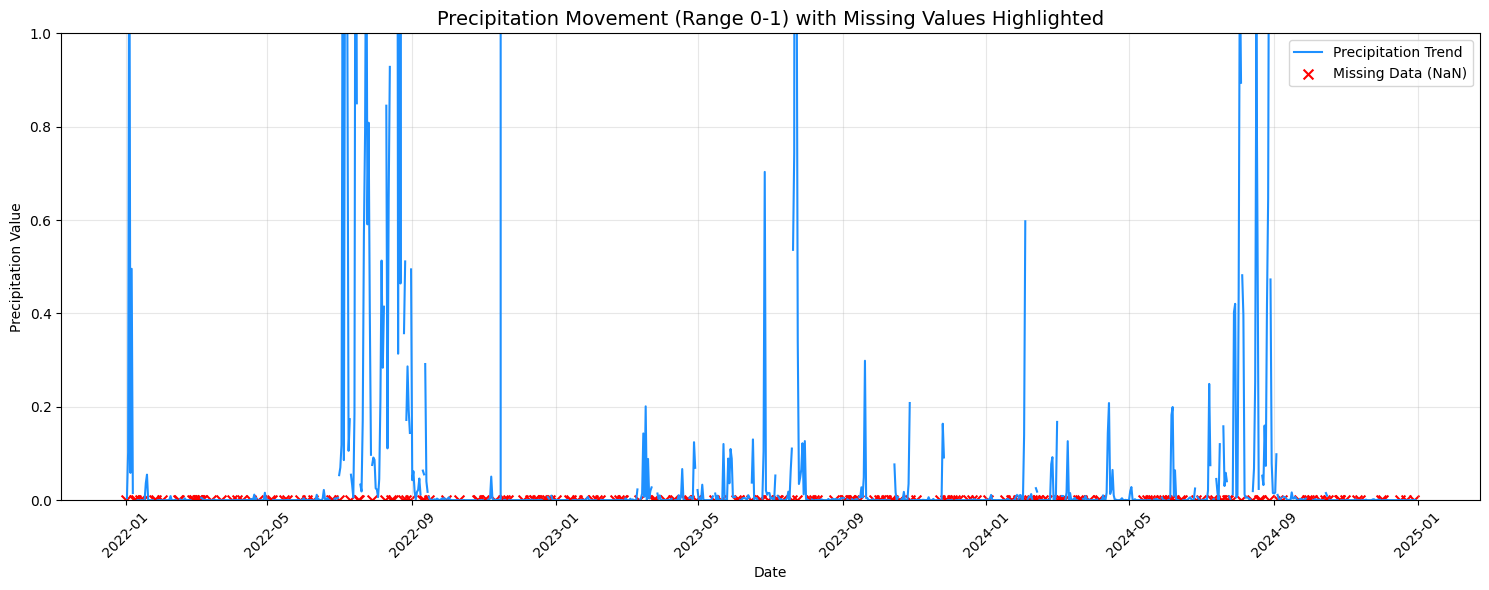

Sorted Data Check (First 100 rows):
         date  precipitation
0  2022-01-01            NaN
1  2022-01-02       0.004603
2  2022-01-02       0.004603
3  2022-01-03       0.102402
4  2022-01-04       1.417323
..        ...            ...
95 2022-03-18       0.000000
96 2022-03-19       0.000000
97 2022-03-19       0.000000
98 2022-03-20       0.000000
99 2022-03-21       0.000000

[100 rows x 2 columns]


In [720]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Date wise sorting
df = df.sort_values('date')

# 2. Missing data points ki location
missing_dates = df[df['precipitation'].isna()]['date']
missing_y = [0] * len(missing_dates)

plt.figure(figsize=(15, 6))

# 3. Asli data plot karna
plt.plot(df['date'], df['precipitation'], label='Precipitation Trend', color='dodgerblue', linewidth=1.5)

# 4. Jahan NaN hai waha 'X' marker lagana
if not missing_dates.empty:
    plt.scatter(missing_dates, missing_y, color='red', marker='x', s=50, label='Missing Data (NaN)')

# --- Y-axis ki range set karna ---
plt.ylim(0, 1)

# Formatting
plt.title('Precipitation Movement (Range 0-1) with Missing Values Highlighted', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Precipitation Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Sorted Data Check
print("Sorted Data Check (First 100 rows):")
print(df[['date', 'precipitation']].head(100))

In [721]:
# 1. Indicator flag (Model ko signal dene ke liye)
df['is_precip_missing'] = df['precipitation'].isna().astype(int)

# 2. Fill with 0 (Factual reality of Pakistan's weather)
df['precipitation'] = df['precipitation'].fillna(0)

In [722]:
df.isna().sum()

,0
date,0
evaporation,2
precipitation,0
pressure,2
soil_moisture,1
temperature,1
water_area_km2,2
wind_speed,2
humidity,1
precip_3day_avg,2


In [723]:
# Us date ko dhoondo jahan aapka error sabse zyada hai
max_error_idx = df['precipitation'].idxmax()
print("DANGEROUS ROW FOUND:")
print(df.loc[max_error_idx-2 : max_error_idx+2, ['date', 'precipitation','precip_3day_avg']])

DANGEROUS ROW FOUND:
          date  precipitation  precip_3day_avg
397 2022-11-14       0.000903         0.000700
398 2022-11-15       0.000125         0.000644
399 2022-11-16     387.400000         0.000400
400 2022-11-17       0.000000         0.000121
401 2022-11-18       0.000479         0.000239


In [724]:
# 1. Sabse pehle realistic capping karo (Sindh/Pakistan ke liye 150-200mm max hai)
# Jo value 200 se upar hai, usay NaN kar do ya cap kar do
df['precipitation'] = df['precipitation'].mask(df['precipitation'] > 200, np.nan)

# 2. Ab NaN ko hamari strategy (Zero) se fill karo
df['precipitation'] = df['precipitation'].fillna(0)

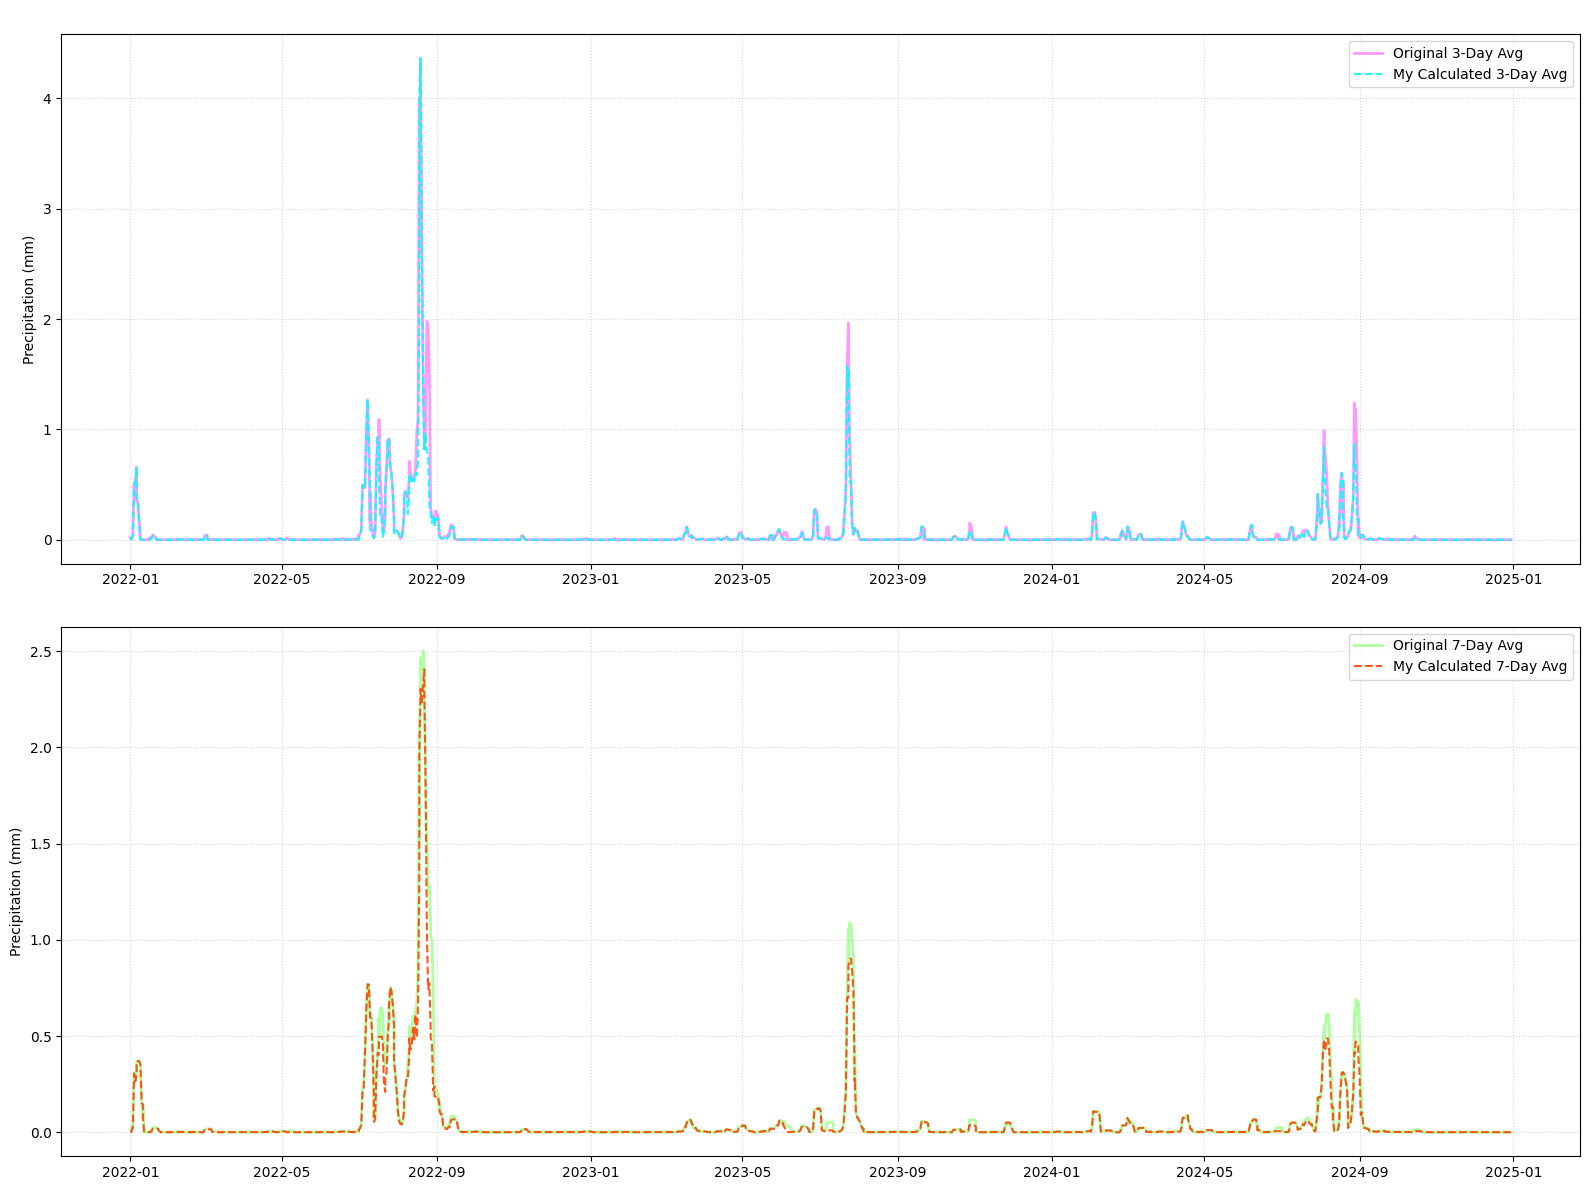

Mean Absolute Error (3-Day): 0.0134 mm
Mean Absolute Error (7-Day): 0.0104 mm


In [725]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Cleaning: Negative values ko 0 karo aur Extreme spikes ko cap karo (e.g., 200mm limit)
df['precipitation'] = df['precipitation'].clip(lower=0).fillna(0)

# 1. Realistic Cap lagao (e.g., 200mm)
df['precipitation'] = df['precipitation'].clip(lower=0, upper=400)

# 2. Phir NaNs ko 0 karo
df['precipitation'] = df['precipitation'].fillna(0)

# 3. Ab dobara Rolling Mean nikalo
# Yeh pehle din se hi average dena shuru kar dega
df['my_precip_3day_avg'] = df['precipitation'].rolling(window=3, min_periods=1).mean()
df['my_precip_7day_avg'] = df['precipitation'].rolling(window=7, min_periods=1).mean()

# 3. Plotting with a Fresh Color Scheme
plt.style.use('default') # Hackathon aesthetic!
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Subplot 1: 3-Day Comparison (Electric Pink vs Cyan)
axes[0].plot(df['date'], df['precip_3day_avg'], label='Original 3-Day Avg', color='#FF00FF', alpha=0.4, linewidth=2)
axes[0].plot(df['date'], df['my_precip_3day_avg'], label='My Calculated 3-Day Avg', color='#00FFFF', alpha=0.9, linestyle='--')
axes[0].set_title('3-Day Rolling Mean: Original (Pink) vs My Logic (Cyan)', color='white', fontsize=16)
axes[0].set_ylabel('Precipitation (mm)')
axes[0].legend()
axes[0].grid(color='gray', linestyle=':', alpha=0.3)

# Subplot 2: 7-Day Comparison (Lime vs Orange)
axes[1].plot(df['date'], df['precip_7day_avg'], label='Original 7-Day Avg', color='#39FF14', alpha=0.4, linewidth=2)
axes[1].plot(df['date'], df['my_precip_7day_avg'], label='My Calculated 7-Day Avg', color='#FF4500', alpha=0.9, linestyle='--')
axes[1].set_title('7-Day Rolling Mean: Original (Lime) vs My Logic (Orange)', color='white', fontsize=16)
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()
axes[1].grid(color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Error Check
mae_3day = np.abs(df['my_precip_3day_avg'] - df['precip_3day_avg']).mean()
print(f"Mean Absolute Error (3-Day): {mae_3day:.4f} mm")

mae_7day = np.abs(df['my_precip_7day_avg'] - df['precip_7day_avg']).mean()
print(f"Mean Absolute Error (7-Day): {mae_7day:.4f} mm")

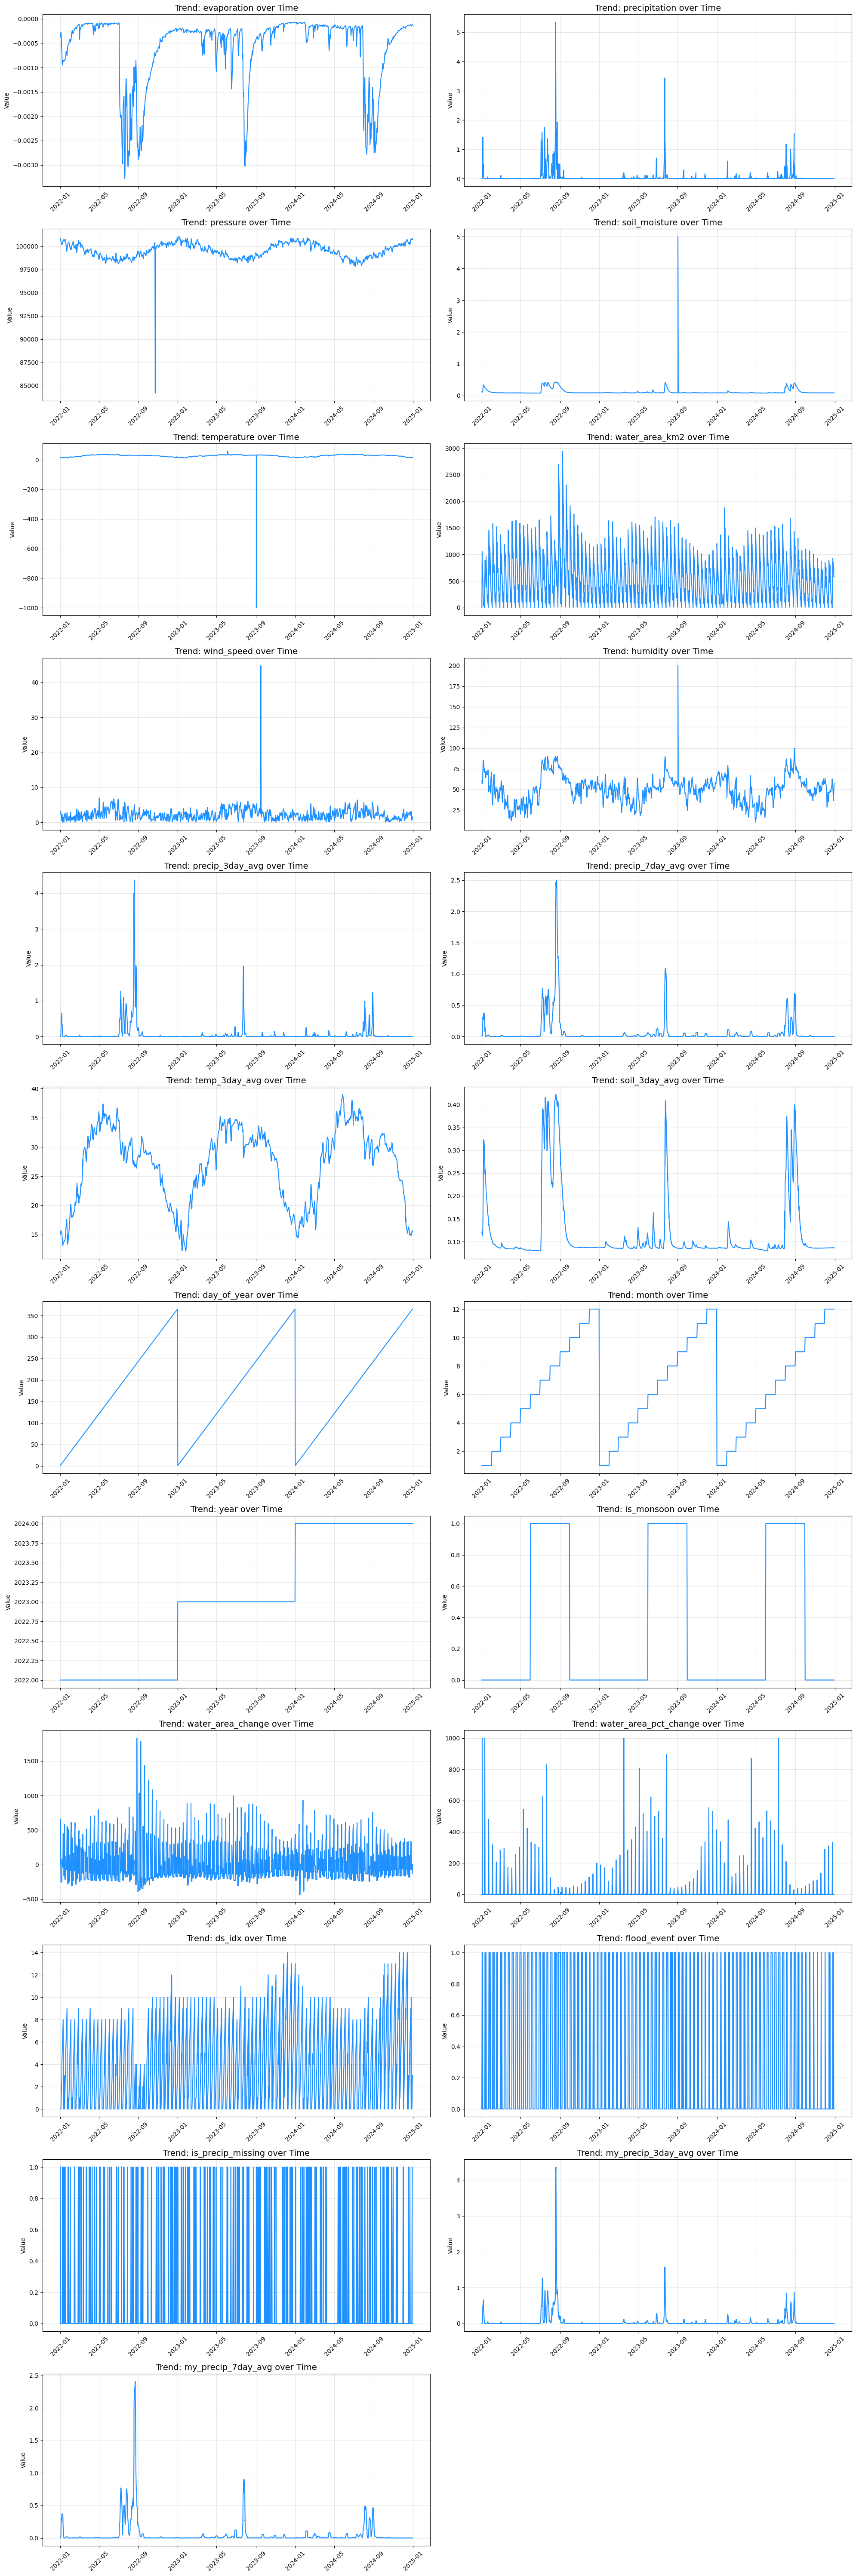

In [726]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Date column ko datetime format mein convert karein (agar pehle se nahi hai)
# Maan lete hain column ka naam 'date' hai
df['date'] = pd.to_datetime(df['date'])

# 2. Numerical columns select karein aur Infinity handle karein
num_df = df.select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan)
numerical_cols = num_df.columns

n_cols = 2 # Line graph ke liye 2 columns behtar hain taake X-axis (dates) khul kar nazar aayein
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    # Cleaning for each plot
    # Hum date aur value dono ko saath rakh rahe hain taake alignment kharab na ho
    temp_df = df[['date', col]].replace([np.inf, -np.inf], np.nan).dropna()

    if not temp_df.empty:
        # Speed ke liye sampling (agar data 2000 rows se zyada hai)
        if len(temp_df) > 2000:
            temp_df = temp_df.iloc[::len(temp_df)//1000]

        plt.plot(temp_df['date'], temp_df[col], color='dodgerblue', linewidth=1.5)
        plt.title(f'Trend: {col} over Time', fontsize=14)
        plt.xticks(rotation=45) # Dates ko rotate kiya taake overlap na ho
    else:
        plt.title(f'{col} (No Valid Data)', fontsize=14)

    plt.grid(True, alpha=0.3)
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [727]:
import numpy as np
import pandas as pd

def clean_environmental_data(df):
    # Data ki copy bana lein taake original kharab na ho
    df_cleaned = df.copy()

    # 1. Soil Moisture: 0.0 to 1.0 (Strict physical limit)
    df_cleaned['soil_moisture'] = df_cleaned['soil_moisture'].clip(0.0, 1.0)

    # 2. Humidity: 0 to 100%
    df_cleaned['humidity'] = df_cleaned['humidity'].clip(0, 100)

    # 3. Temperature: Sindh/Pakistan logic (-10 to 55 degrees is safe for daily mean)
    # Isse bahar wali values ko hum NaN kar denge taake outliers nikal jayein
    df_cleaned.loc[(df_cleaned['temperature'] < -10) | (df_cleaned['temperature'] > 55), 'temperature'] = np.nan

    # 4. Precipitation & Wind Speed: Cannot be negative
    if 'precipitation' in df_cleaned.columns:
        df_cleaned['precipitation'] = df_cleaned['precipitation'].clip(lower=0)
    df_cleaned['wind_speed'] = df_cleaned['wind_speed'].clip(lower=0)



    # 5. Water Area Change Logic
    # Agar change actual area se bohot zyada hai (e.g., 10 times more), toh use cap karein
    # Hum limit set karte hain ke change area ke 2x se zyada na ho (ya jo bhi aapki requirement ho)
    if 'water_area_change' in df_cleaned.columns and 'water_area_km2' in df_cleaned.columns:
        max_allowed_change = df_cleaned['water_area_km2'] * 2
        df_cleaned['water_area_change'] = np.where(
            df_cleaned['water_area_change'] > max_allowed_change,
            max_allowed_change,
            df_cleaned['water_area_change']
        )

    # 6. Final Touch: Jo NaN temperature mein aaye hain, unhein interpolate kar lein
    # Taake graph mein "holes" nazar na aayein
    df_cleaned = df_cleaned.interpolate(method='linear')

    return df_cleaned

# Apply the cleaning
df = clean_environmental_data(df)

print("Cleaning Complete! Sab 'Phantom' values theek kar di gayi hain.")

Cleaning Complete! Sab 'Phantom' values theek kar di gayi hain.


/tmp/ipykernel_6765/241972195.py:38: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_cleaned = df_cleaned.interpolate(method='linear')


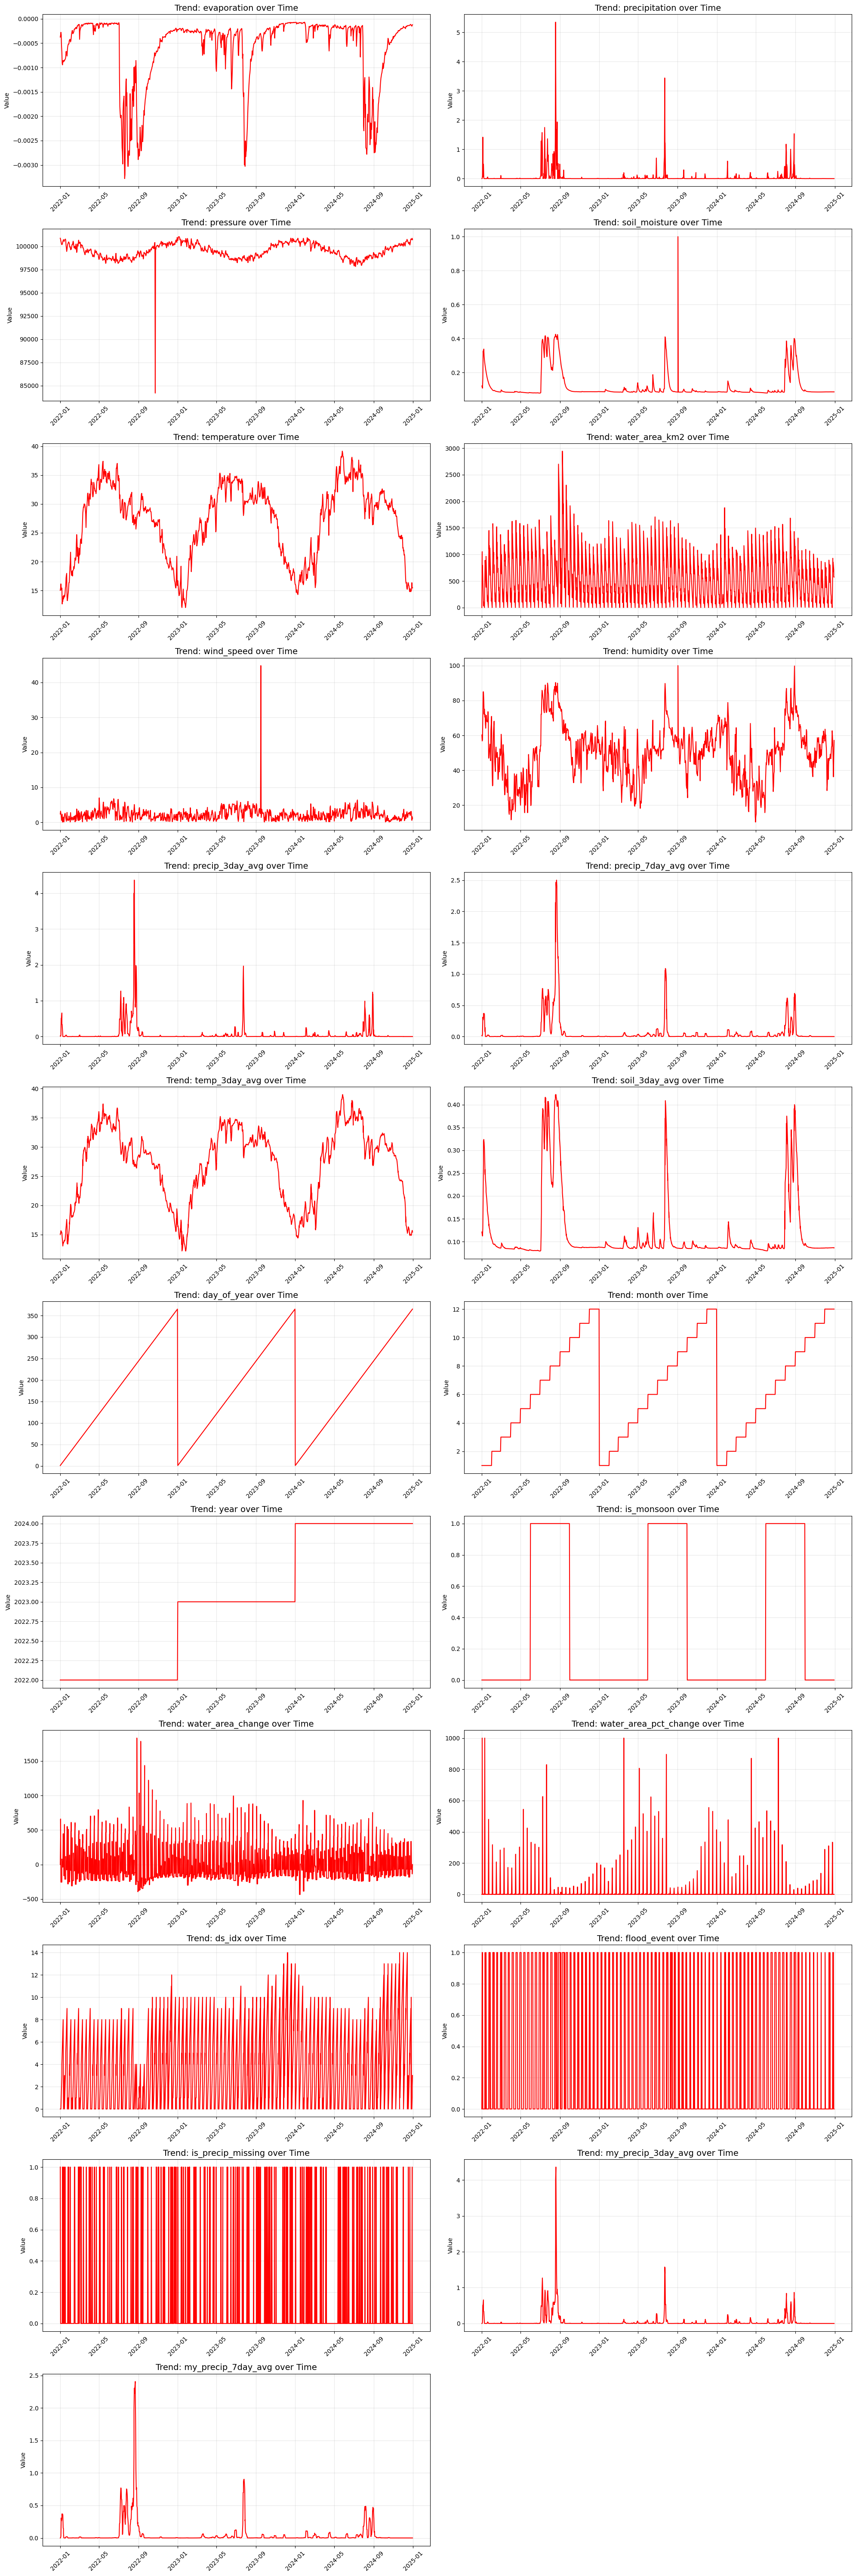

In [728]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Date column ko datetime format mein convert karein (agar pehle se nahi hai)
# Maan lete hain column ka naam 'date' hai
df['date'] = pd.to_datetime(df['date'])

# 2. Numerical columns select karein aur Infinity handle karein
num_df = df.select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan)
numerical_cols = num_df.columns

n_cols = 2 # Line graph ke liye 2 columns behtar hain taake X-axis (dates) khul kar nazar aayein
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    # Cleaning for each plot
    # Hum date aur value dono ko saath rakh rahe hain taake alignment kharab na ho
    temp_df = df[['date', col]].replace([np.inf, -np.inf], np.nan).dropna()

    if not temp_df.empty:
        # Speed ke liye sampling (agar data 2000 rows se zyada hai)
        if len(temp_df) > 2000:
            temp_df = temp_df.iloc[::len(temp_df)//1000]

        plt.plot(temp_df['date'], temp_df[col], color='red', linewidth=1.5)
        plt.title(f'Trend: {col} over Time', fontsize=14)
        plt.xticks(rotation=45) # Dates ko rotate kiya taake overlap na ho
    else:
        plt.title(f'{col} (No Valid Data)', fontsize=14)

    plt.grid(True, alpha=0.3)
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [729]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1367 entries, 0 to 1366
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1367 non-null   datetime64[ns]
 1   evaporation            1367 non-null   float64       
 2   precipitation          1367 non-null   float64       
 3   pressure               1367 non-null   float64       
 4   soil_moisture          1367 non-null   float64       
 5   temperature            1367 non-null   float64       
 6   water_area_km2         1367 non-null   float64       
 7   wind_speed             1367 non-null   float64       
 8   humidity               1367 non-null   float64       
 9   precip_3day_avg        1367 non-null   float64       
 10  precip_7day_avg        1367 non-null   float64       
 11  temp_3day_avg          1367 non-null   float64       
 12  soil_3day_avg          1367 non-null   float64       
 13  day_of_y

In [730]:
df.isnull().sum()

,0
date,0
evaporation,0
precipitation,0
pressure,0
soil_moisture,0
temperature,0
water_area_km2,0
wind_speed,0
humidity,0
precip_3day_avg,0


In [731]:
#no inf water pct
import numpy as np

inf_water_area_pct_change_rows = df[np.isinf(df['water_area_pct_change'])]
display(inf_water_area_pct_change_rows)

print(f"Number of rows with infinite 'water_area_pct_change': {len(inf_water_area_pct_change_rows)}")

,date,evaporation,precipitation,pressure,soil_moisture,temperature,water_area_km2,wind_speed,humidity,precip_3day_avg,...,year,is_monsoon,water_area_change,water_area_pct_change,ds_idx,flood_event,district,is_precip_missing,my_precip_3day_avg,my_precip_7day_avg


Number of rows with infinite 'water_area_pct_change': 0


/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


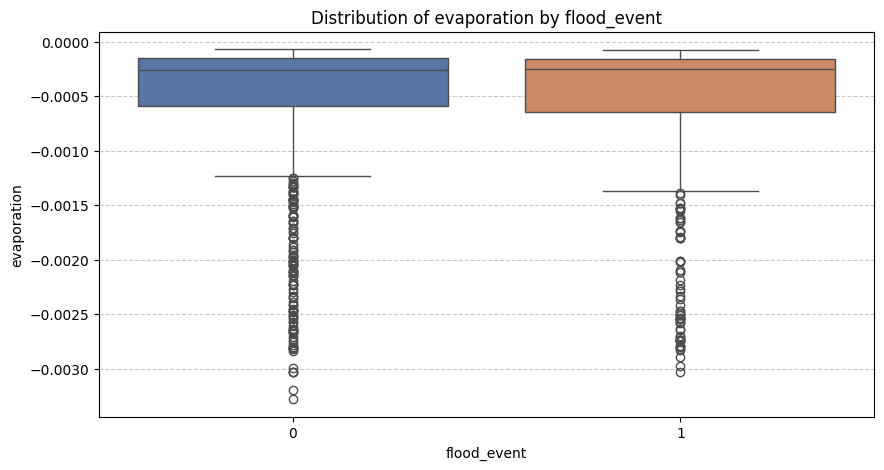

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


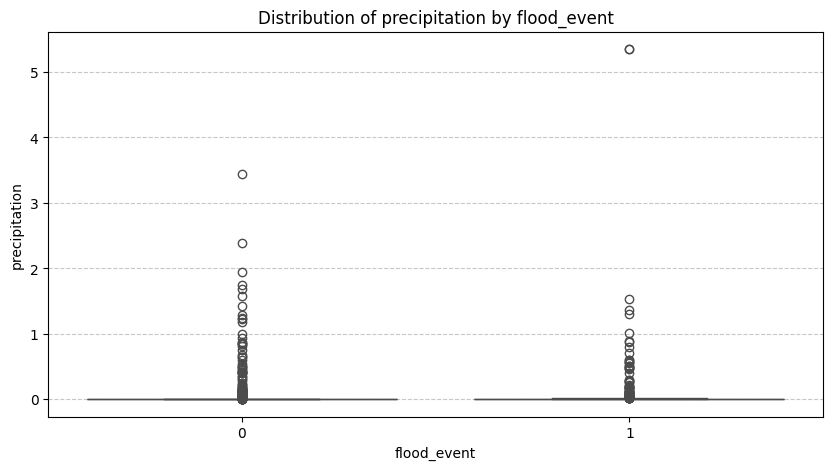

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


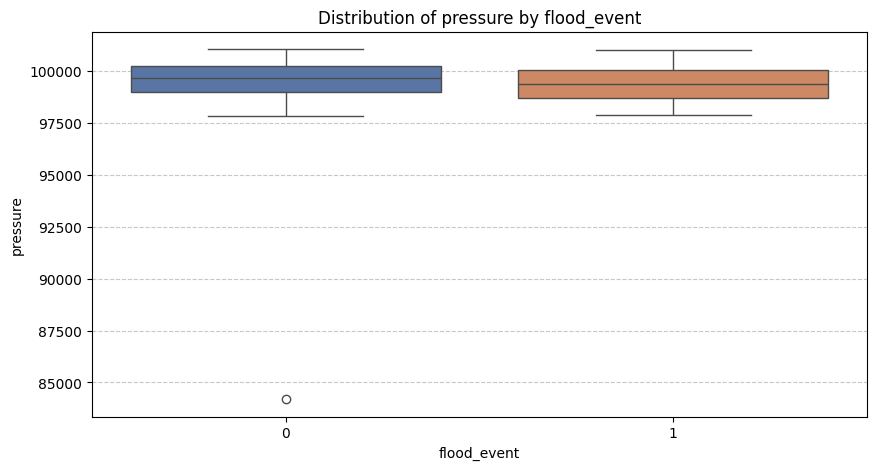

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


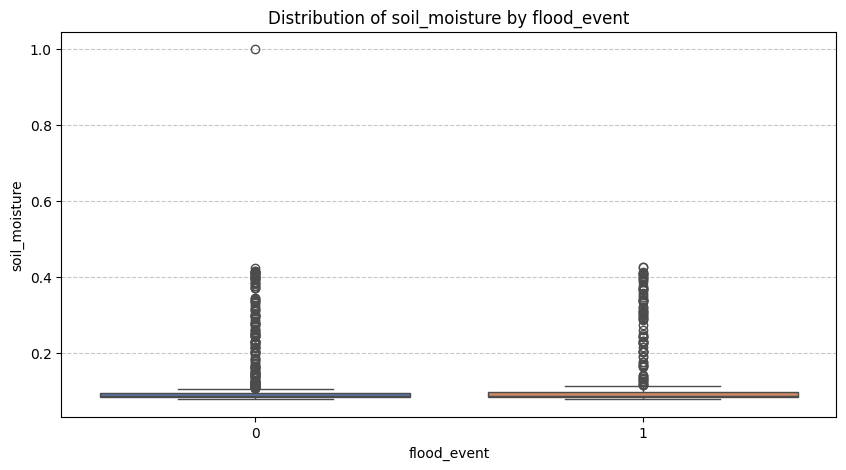

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


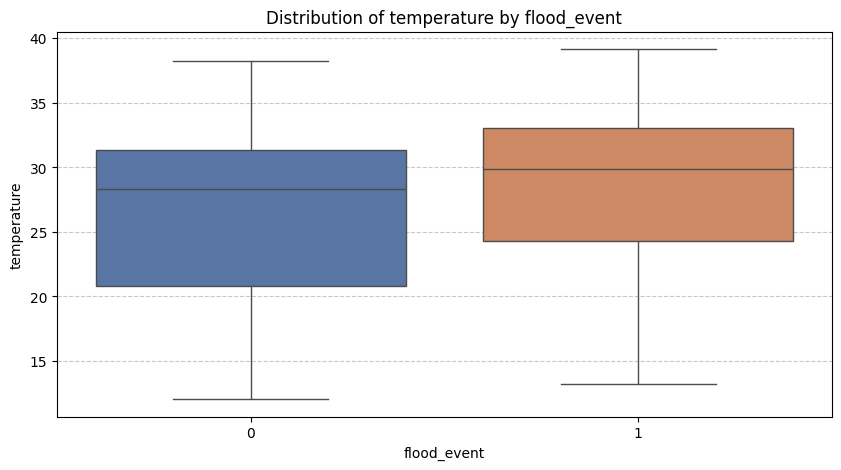

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


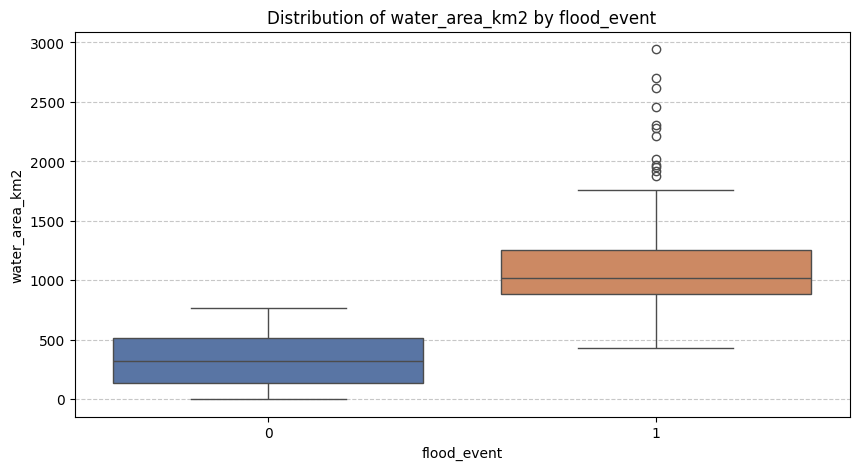

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


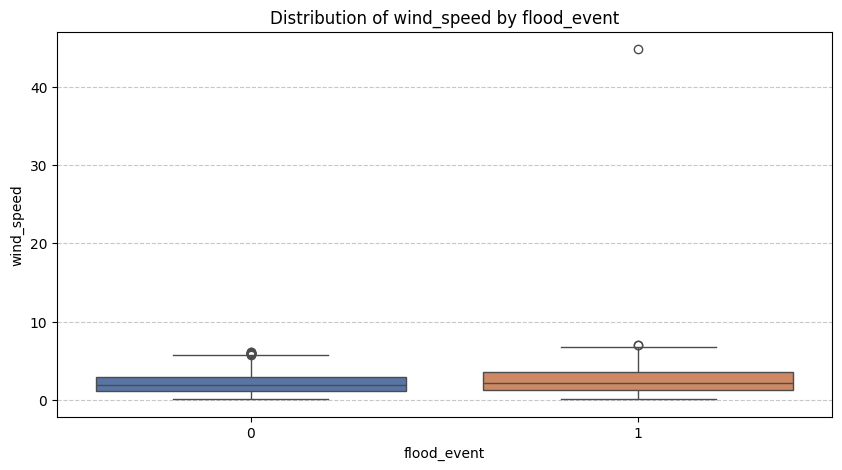

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


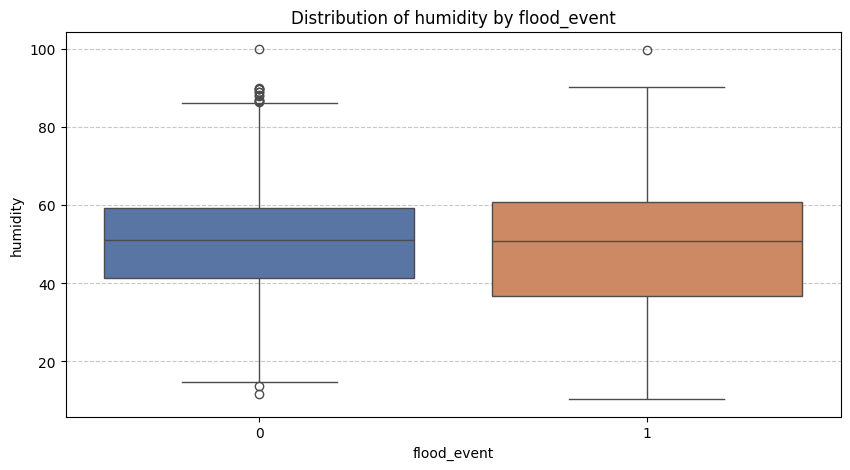

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


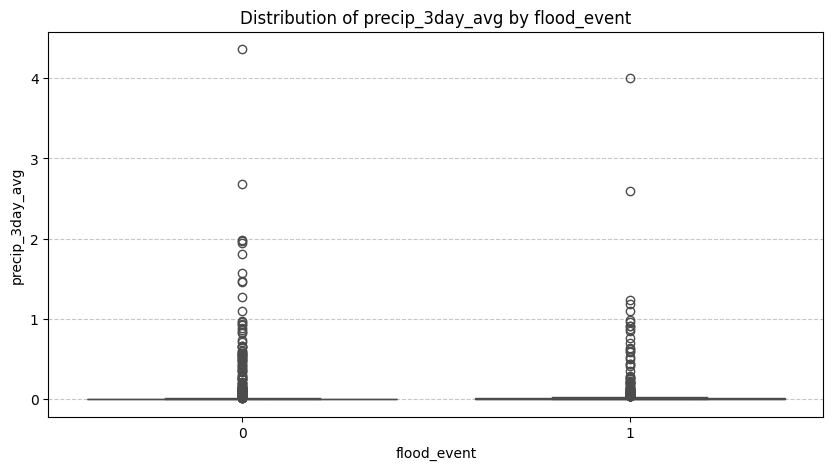

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


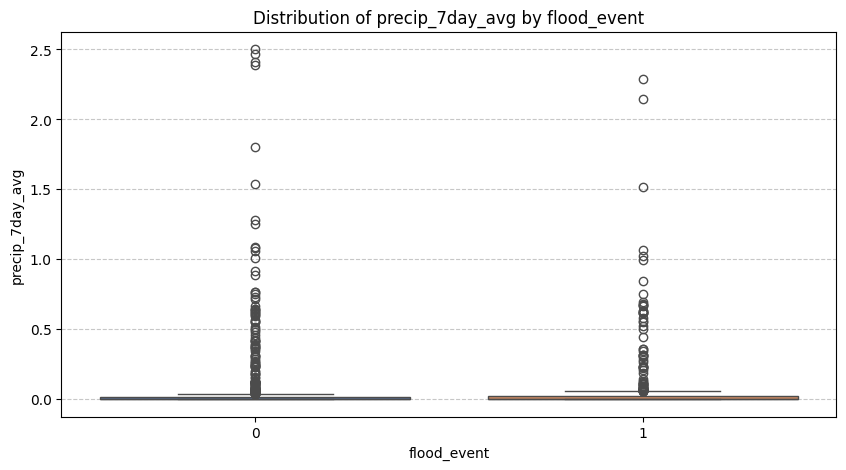

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


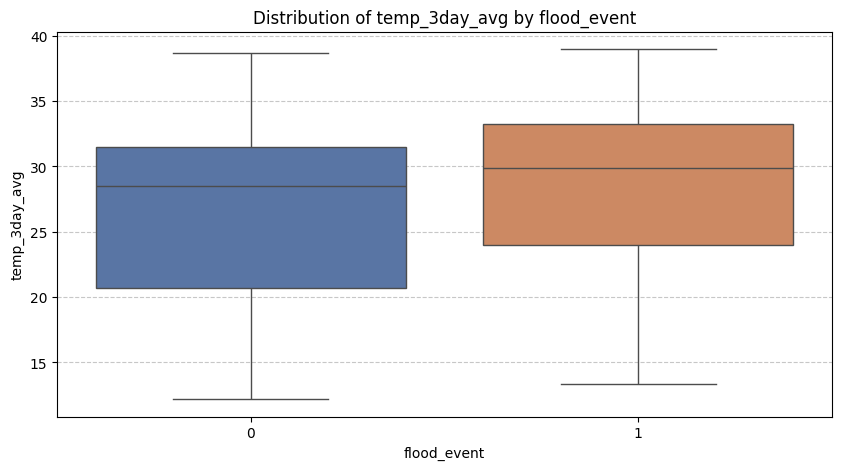

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


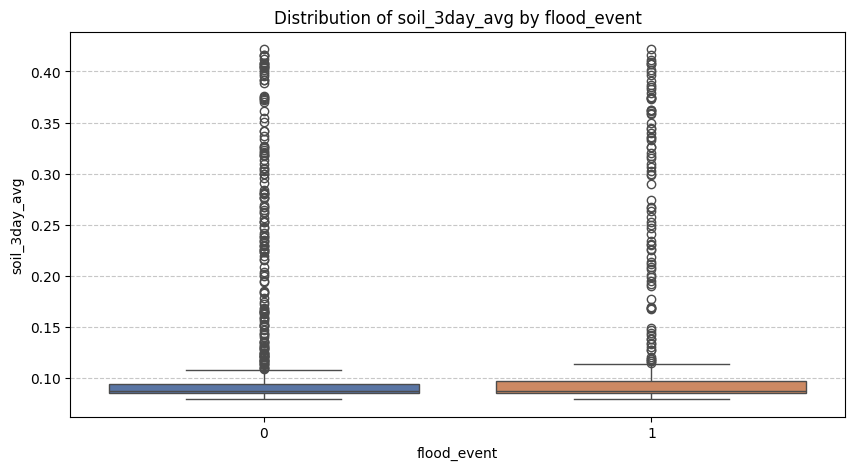

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


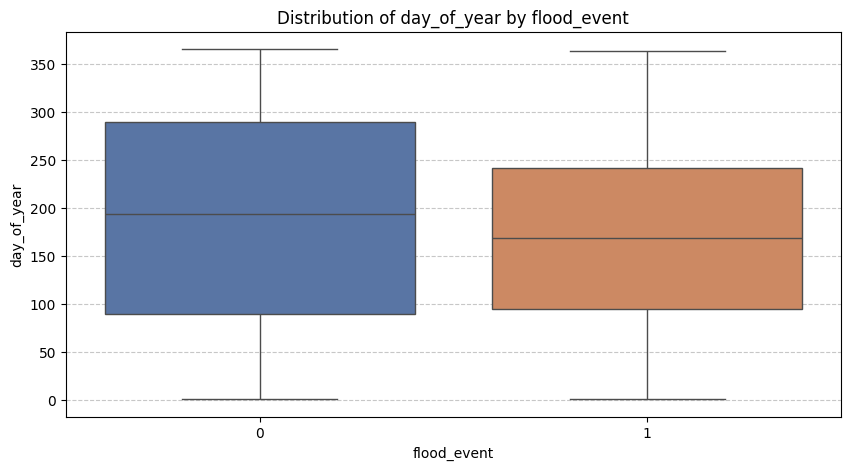

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


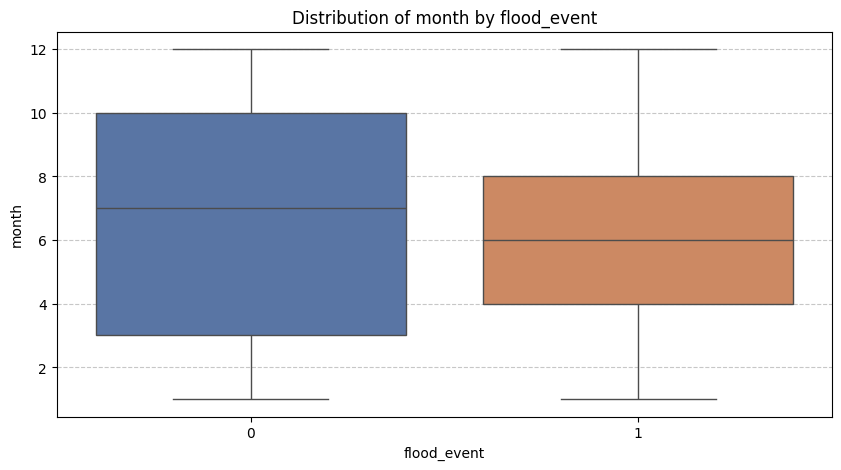

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


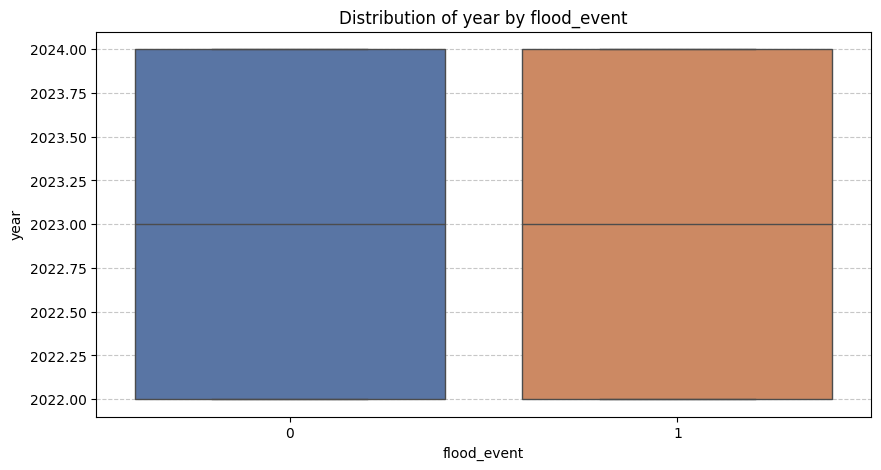

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


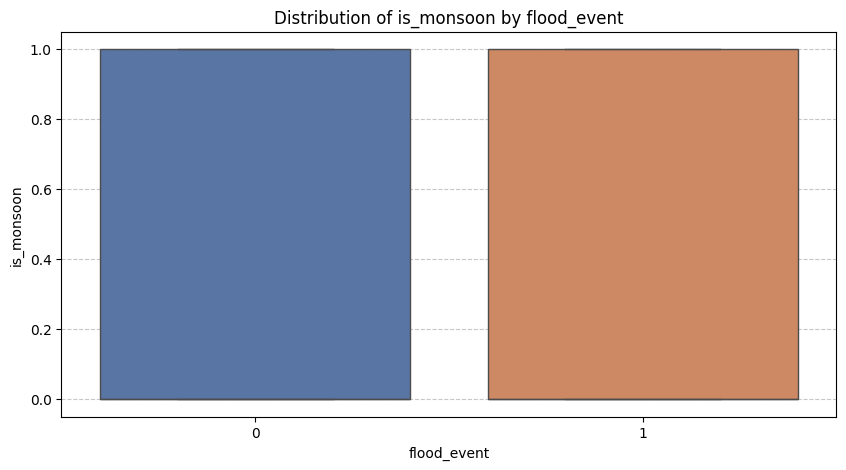

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


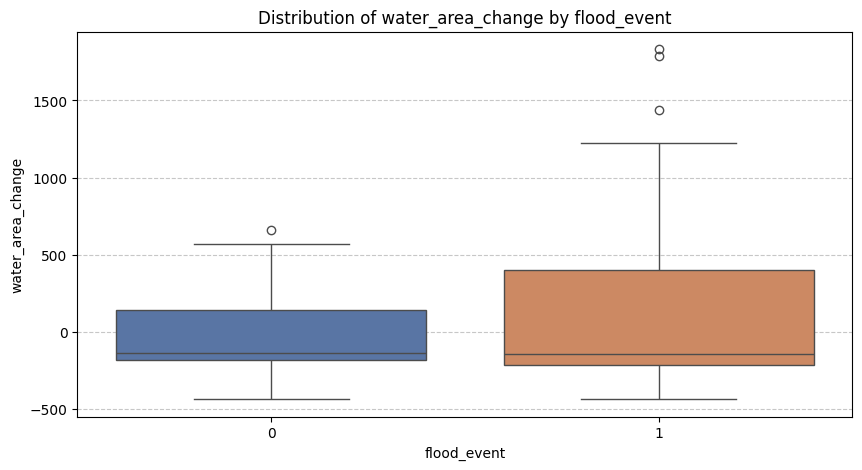

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


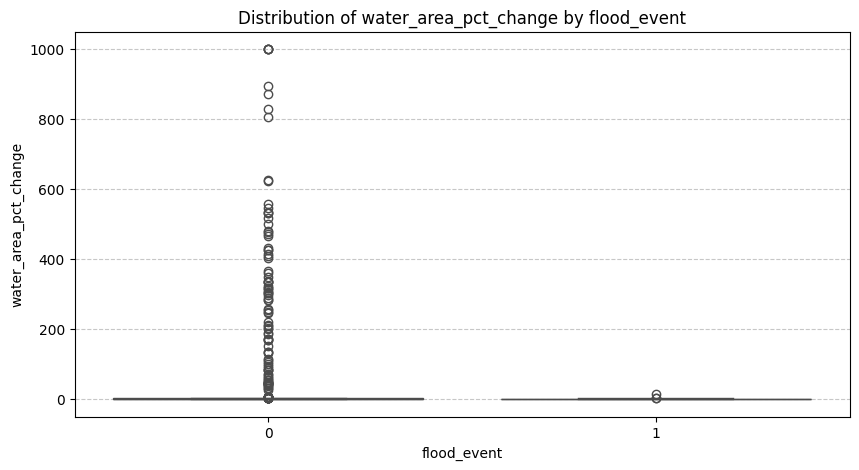

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


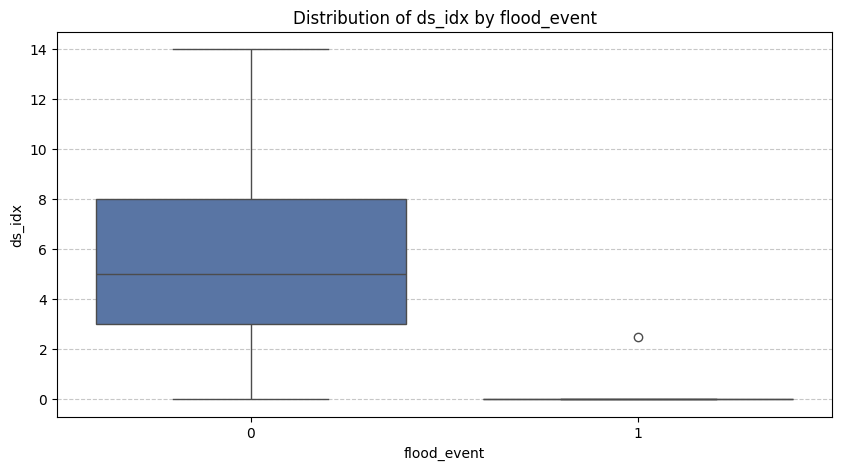

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


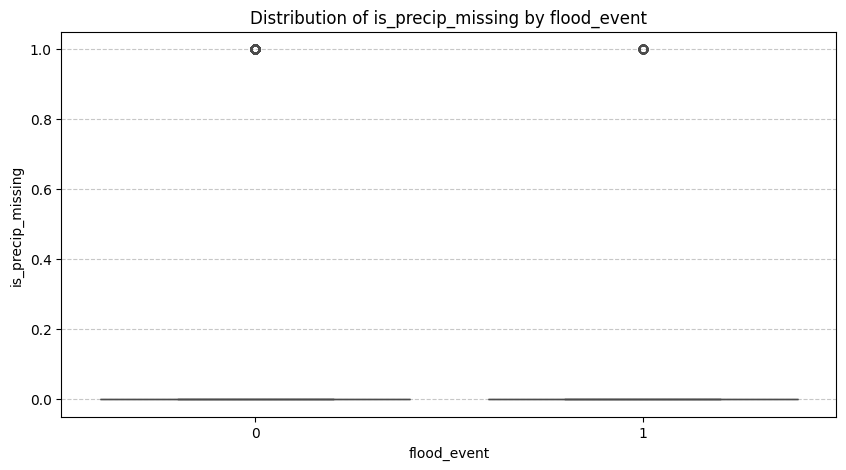

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


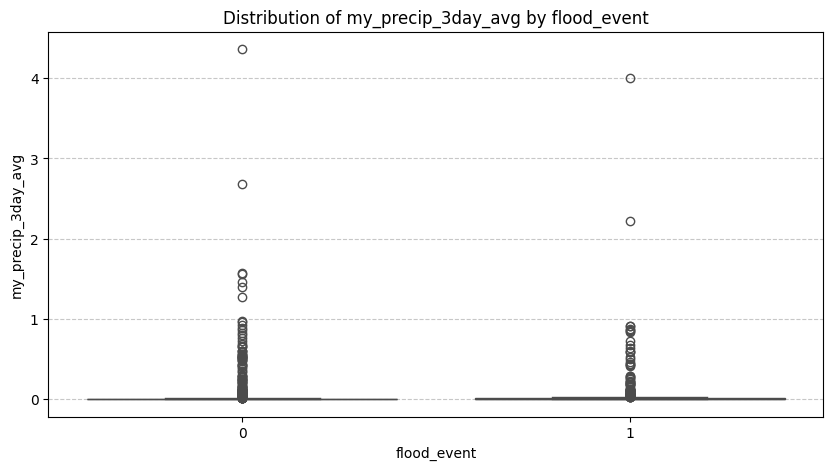

/tmp/ipykernel_6765/4273206451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[target], y=df[col], palette='deep')


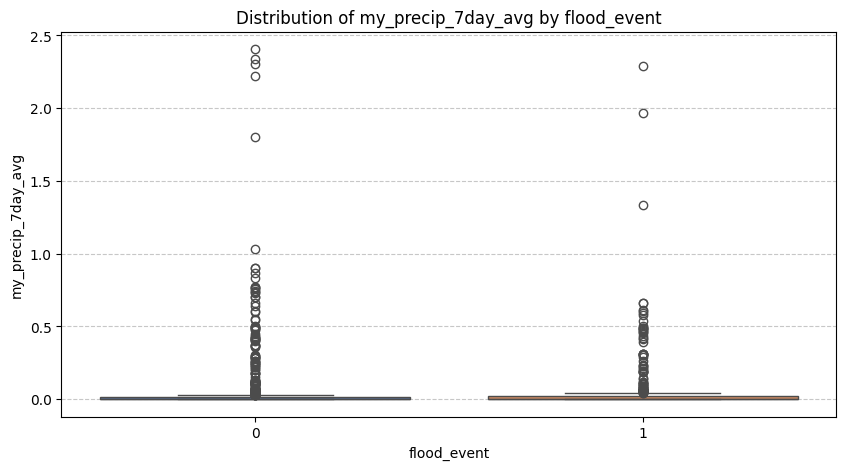

In [732]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Target column ka sahi naam set karein (Jo aapke error mein tha)
target = 'flood_event'

# 2. Sirf numerical columns uthayein (unhein hi boxplot mein daal sakte hain)
# 'date' aur 'flood_event' ko nikaal denge list se
cols_to_plot = df.select_dtypes(include=['number']).columns.tolist()
if target in cols_to_plot:
    cols_to_plot.remove(target)

# 3. Loop through all columns
for col in cols_to_plot:
    try:
        plt.figure(figsize=(10, 5))

        # Standard colors: Blue for 0, Orange for 1
        sns.boxplot(x=df[target], y=df[col], palette='deep')

        plt.title(f'Distribution of {col} by {target}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

    except Exception as e:
        print(f"Column {col} plot nahi ho saka: {e}")

In [733]:
df = df.drop(columns=['year', 'ds_idx', 'date'], errors='ignore')

In [734]:
# 1. Saare Unique Districts ki list dekhne ke liye
print("Unique Districts in Dataset:")
print(df['district'].unique())


# 3. Agar aap alphabetical order mein dekhna chahte hain
print("\nSorted District Names:")
print(sorted(df['district'].unique()))

Unique Districts in Dataset:
['Sindh_District' 'Balochistan_District' 'Nowshera' 'Jacobabad'
 'KP_District']

Sorted District Names:
['Balochistan_District', 'Jacobabad', 'KP_District', 'Nowshera', 'Sindh_District']


In [735]:
import pandas as pd

# 1. Reference data ko load karein
# Note: Agar aapne file upload ki hai toh sahi path check kar lein
ref_df = pd.read_csv("district_elevation_reference.csv")

# 2. Merge karne se pehle column names check kar lein
# Aapke main df mein column 'district' hai aur ref_df mein 'district'
# Dono ko merge karte hain
df = pd.merge(df, ref_df, on='district', how='left')


print(f"\nTotal rows after merge: {len(df)}")


Total rows after merge: 1367


In [736]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   evaporation            1367 non-null   float64
 1   precipitation          1367 non-null   float64
 2   pressure               1367 non-null   float64
 3   soil_moisture          1367 non-null   float64
 4   temperature            1367 non-null   float64
 5   water_area_km2         1367 non-null   float64
 6   wind_speed             1367 non-null   float64
 7   humidity               1367 non-null   float64
 8   precip_3day_avg        1367 non-null   float64
 9   precip_7day_avg        1367 non-null   float64
 10  temp_3day_avg          1367 non-null   float64
 11  soil_3day_avg          1367 non-null   float64
 12  day_of_year            1367 non-null   float64
 13  month                  1367 non-null   int64  
 14  is_monsoon             1367 non-null   int64  
 15  wate

In [737]:
import pandas as pd
import numpy as np

def preprocess_flood_data(df):
    # --- STEP 1: DEDUPLICATION & INITIAL CLEANING ---
    # Remove duplicate rows before any splits
    df = df.drop_duplicates().reset_index(drop=True)



    # --- STEP 2: PHANTOM ROW FILTERING (Impossible Values) ---
    # Detect and exclude impossible sensor readings
    initial_rows = len(df)
    df = df[
        (df['humidity'].between(0, 100)) &
        (df['soil_moisture'].between(0, 1)) &
        (df['precipitation'] >= 0) &
        (df['temperature'].between(-10, 60)) &
        (df['wind_speed'] >= 0)
    ]
    print(f"Removed {initial_rows - len(df)} phantom rows.")

    # --- STEP 3: INF & NAN HANDLING ---
    # Handle 'inf' in percentage change columns [cite: 129, 142]
    # Replace with high constant (99th percentile) or clip
    if 'water_area_pct_change' in df.columns:
        upper_limit = df['water_area_pct_change'].replace([np.inf, -np.inf], np.nan).quantile(0.99)
        df['water_area_pct_change'] = df['water_area_pct_change'].replace([np.inf, -np.inf], upper_limit).fillna(0)

    # Impute precipitation NaNs district-wise to avoid crashing [cite: 126, 142]
    df['precipitation'] = df.groupby('district')['precipitation'].transform(lambda x: x.fillna(x.median()))

    # --- STEP 4: TERRAIN MERGE ---
    # Merge district elevation and terrain type [cite: 157, 158]


    # --- STEP 5: FEATURE ENGINEERING (Lags & Interactions) ---
    # Strong models use cumulative patterns
    df = df.sort_values(by=['district', 'month', 'day_of_year'])

    # Lag Features (Past 1-2 days)
    for lag in [1, 2]:
        df[f'precip_lag{lag}'] = df.groupby('district')['precipitation'].shift(lag)
        df[f'soil_lag{lag}'] = df.groupby('district')['soil_moisture'].shift(lag)

    # Interaction Features: The "Physics" of Flooding
    # Saturated soil + heavy rain = Critical Risk
    df['saturation_impact'] = df['precipitation'] * df['soil_moisture']

    # Low-lying districts are at higher risk for the same rainfall
    df['elevation_risk'] = df['precipitation'] / (df['avg_elevation_m'] + 1)

    # Seasonal stress interaction
    df['monsoon_intensity'] = df['is_monsoon'] * df['precip_7day_avg']

    # --- STEP 6: ENCODING ---
    # Convert categories to numeric for the Tree model
    t_map = {'Flat floodplain': 3, 'River valley': 2, 'Semi-arid plateau': 1}
    df['terrain_danger_score'] = df['terrain_type'].map(t_map)

    # One-Hot Encode for identity (e.g., KP_District, Sindh_District)
    df = pd.get_dummies(df, columns=['terrain_type'], drop_first=True)

    # Final drop of non-numeric 'date' if it still exists
    if 'date' in df.columns:
        df = df.drop(columns=['date'])

    return df.fillna(0) # Final safety fill for early-date lags

# Usage:
df = preprocess_flood_data(df)

Removed 0 phantom rows.


In [738]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1367 entries, 456 to 455
Data columns (total 35 columns):
 #   Column                                                                                Non-Null Count  Dtype  
---  ------                                                                                --------------  -----  
 0   evaporation                                                                           1367 non-null   float64
 1   precipitation                                                                         1367 non-null   float64
 2   pressure                                                                              1367 non-null   float64
 3   soil_moisture                                                                         1367 non-null   float64
 4   temperature                                                                           1367 non-null   float64
 5   water_area_km2                                                                        1

In [739]:
columns_to_drop = [
    'my_precip_3day_avg',
    'my_precip_7day_avg',
    'terrain_type_Flat floodplain — Dadu monitoring station elevation (confirmed)',
    'terrain_type_River valley on Kabul River — high flood risk due to proximity to river',
    'terrain_type_River valley — Nowshera city elevation on Kabul River plain',
    'terrain_type_Semi-arid plateau — Balochistan plateau average elevation'
]
df = df.drop(columns=columns_to_drop, errors='ignore')
print(f"Dropped {len(columns_to_drop)} columns. New DataFrame shape: {df.shape}")

Dropped 6 columns. New DataFrame shape: (1367, 29)


In [740]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1367 entries, 456 to 455
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   evaporation            1367 non-null   float64
 1   precipitation          1367 non-null   float64
 2   pressure               1367 non-null   float64
 3   soil_moisture          1367 non-null   float64
 4   temperature            1367 non-null   float64
 5   water_area_km2         1367 non-null   float64
 6   wind_speed             1367 non-null   float64
 7   humidity               1367 non-null   float64
 8   precip_3day_avg        1367 non-null   float64
 9   precip_7day_avg        1367 non-null   float64
 10  temp_3day_avg          1367 non-null   float64
 11  soil_3day_avg          1367 non-null   float64
 12  day_of_year            1367 non-null   float64
 13  month                  1367 non-null   int64  
 14  is_monsoon             1367 non-null   int64  
 15  water_ar

In [741]:
import pandas as pd
import numpy as np

def inject_monsoon_surge_categorical(df, districts_to_spike=['Nowshera', 'Sindh_District']):
    new_rows = []

    for dist_name in districts_to_spike:
        # 1. Filter using the text column 'district'
        # We only take monsoon data to get a realistic 'High Rain' baseline
        mask = (df['district'] == dist_name) & (df['is_monsoon'] == 1)

        if not mask.any():
            print(f"Warning: No baseline data found for {dist_name}. Skipping.")
            continue

        # Get numeric mean for the baseline
        baseline = df[mask].mean(numeric_only=True)

        # 2. Create the 300% Spike (Original + 300% = 4x the mean)
        spike_data = baseline.to_dict()
        spike_data['district'] = dist_name  # Put the text name back in
        spike_data['precipitation'] = baseline['precipitation'] * 4
        spike_data['flood_event'] = 1  # Confirmed flood event

        # 3. Re-calculate your "Secret Sauce" Interaction Features
        # These must reflect the new extreme rainfall
        spike_data['saturation_impact'] = spike_data['precipitation'] * spike_data['soil_moisture']

        # Elevation Risk: Low-lying districts are more vulnerable [cite: 142]
        # Formula: $Precipitation / (avg\_elevation\_m + 1)$
        spike_data['elevation_risk'] = spike_data['precipitation'] / (spike_data['avg_elevation_m'] + 1)

        # Add timestamp for context (Optional, for your pitch)
        spike_data['date'] = pd.to_datetime("2026-05-08") # Scenario date

        new_rows.append(spike_data)

    # 4. Append to training data
    df_surge = pd.DataFrame(new_rows)
    updated_df = pd.concat([df, df_surge], ignore_index=True)

    print(f"✅ Injected 300% spike rows for: {districts_to_spike}")
    return updated_df

# Usage:
df = inject_monsoon_surge_categorical(df)

✅ Injected 300% spike rows for: ['Nowshera', 'Sindh_District']


In [742]:
import pandas as pd

def fix_rogue_sensor(df):
    # 1. Define the target and its neighbors
    faulty_dist = "Jacobabad"
    proxies = ["Sindh_District", "Balochistan_District"]

    # 2. Calculate the daily average of the two neighbors
    # We group by date to ensure we are averaging matching time periods
    neighbor_avg = df[df['district'].isin(proxies)].groupby('date')['precipitation'].mean()

    # 3. Map these averages back to the faulty district's rows
    # We use 'map' on the date column to fill only Jacobabad's precipitation
    df.loc[df['district'] == faulty_dist, 'precipitation'] = df['date'].map(neighbor_avg)

    # 4. Final Safety Check: If any dates didn't match, use the neighbor's median
    fallback = df[df['district'].isin(proxies)]['precipitation'].median()
    df.loc[df['district'] == faulty_dist, 'precipitation'] = df.loc[df['district'] == faulty_dist, 'precipitation'].fillna(fallback)

    print(f"Bonus Challenge: Imputed {faulty_dist} using {proxies}")
    return df

# Apply this before retraining
df = fix_rogue_sensor(df)

Bonus Challenge: Imputed Jacobabad using ['Sindh_District', 'Balochistan_District']


In [743]:
df.shape

(1369, 30)

In [744]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   evaporation            1369 non-null   float64       
 1   precipitation          1369 non-null   float64       
 2   pressure               1369 non-null   float64       
 3   soil_moisture          1369 non-null   float64       
 4   temperature            1369 non-null   float64       
 5   water_area_km2         1369 non-null   float64       
 6   wind_speed             1369 non-null   float64       
 7   humidity               1369 non-null   float64       
 8   precip_3day_avg        1369 non-null   float64       
 9   precip_7day_avg        1369 non-null   float64       
 10  temp_3day_avg          1369 non-null   float64       
 11  soil_3day_avg          1369 non-null   float64       
 12  day_of_year            1369 non-null   float64       
 13  mon

### Data Splitting and Random Forest Model


In [745]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Define features (X) and target (y)
# Drop 'district' as it's categorical and not yet one-hot encoded for all districts.
# Drop 'date' as it's datetime object and has many NaNs after surge injection, not directly usable by RF.
# 'is_precip_missing' is also a feature.

df = df.sort_values(by=['district', 'date'])
df['water_area_lag1'] = df.groupby('district')['water_area_km2'].shift(1)
df['water_change_lag1'] = df.groupby('district')['water_area_change'].shift(1)

# 2. Fill NaNs (First day of each district will be NaN)
df['water_area_lag1'] = df['water_area_lag1'].fillna(0)
df['water_change_lag1'] = df['water_change_lag1'].fillna(0)


df = pd.get_dummies(df, columns=['district'], prefix='loc')
X = df.drop(columns=['flood_event', 'district', 'date',
    'water_area_km2', 'water_area_change','water_area_pct_change','temp_3day_avg','evaporation','is_precip_missing',	'avg_elevation_m'], errors='ignore')
y = df['flood_event']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1095, 27)
Shape of X_test: (274, 27)
Shape of y_train: (1095,)
Shape of y_test: (274,)


In [752]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 0 to 1366
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   precipitation             1369 non-null   float64
 1   pressure                  1369 non-null   float64
 2   soil_moisture             1369 non-null   float64
 3   temperature               1369 non-null   float64
 4   wind_speed                1369 non-null   float64
 5   humidity                  1369 non-null   float64
 6   precip_3day_avg           1369 non-null   float64
 7   precip_7day_avg           1369 non-null   float64
 8   soil_3day_avg             1369 non-null   float64
 9   day_of_year               1369 non-null   float64
 10  month                     1369 non-null   float64
 11  is_monsoon                1369 non-null   float64
 12  precip_lag1               1369 non-null   float64
 13  soil_lag1                 1369 non-null   float64
 14  precip_lag2  

In [746]:
# Initialize and train a RandomForestClassifier
# Using a small number of estimators for demonstration purposes
# Force the model to pay more attention to the 'Flood' (1) cases
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       185
           1       0.77      0.75      0.76        89

    accuracy                           0.85       274
   macro avg       0.83      0.82      0.82       274
weighted avg       0.85      0.85      0.85       274

Accuracy:
0.8467153284671532

Confusion Matrix:


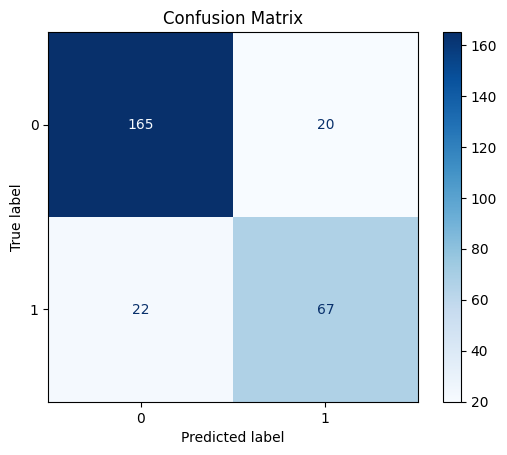

In [747]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

# Display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

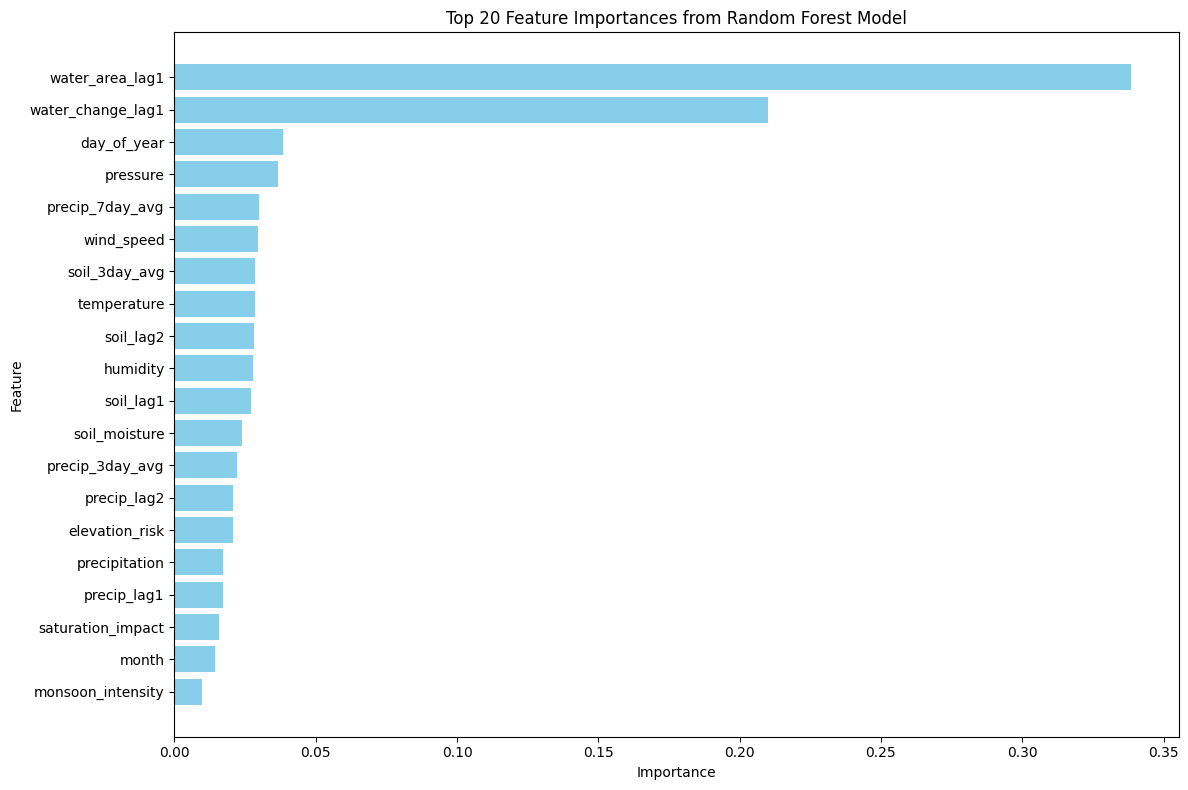

,Feature,Importance
20,water_area_lag1,0.338510
21,water_change_lag1,0.209997
9,day_of_year,0.038498
1,pressure,0.036767
7,precip_7day_avg,0.030079
4,wind_speed,0.029670
8,soil_3day_avg,0.028381
3,temperature,0.028348
15,soil_lag2,0.028122
5,humidity,0.027826


In [748]:
# Get feature importances
feature_importances = model.feature_importances_
features = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'][:20], importance_df['Importance'][:20], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances from Random Forest Model')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()

display(importance_df.head(20))

In [749]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


# --- 3. THE 80% MASTER MODEL (XGBoost) ---
# scale_pos_weight is the secret sauce for the 32% minority class
model = XGBClassifier(
    n_estimators=500,           # Ziada trees for complex decision boundaries
    learning_rate=0.03,         # Slower learning = better generalization
    max_depth=6,                # Captures interactions like (Rain * Soil * Elevation)
    scale_pos_weight=2.1,       # Ratio of Non-Flood to Flood (68/32)
    subsample=0.8,              # Prevents overfitting to specific rows
    colsample_bytree=0.8,       # Prevents overfitting to specific features
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# --- 4. THE VERDICT ---
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"🔥 XGBoost Accuracy: {acc:.2f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

🔥 XGBoost Accuracy: 0.86

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.87      0.89       185
           1       0.76      0.84      0.80        89

    accuracy                           0.86       274
   macro avg       0.84      0.86      0.85       274
weighted avg       0.87      0.86      0.86       274



In [750]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 0 to 1366
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   precipitation             1369 non-null   float64
 1   pressure                  1369 non-null   float64
 2   soil_moisture             1369 non-null   float64
 3   temperature               1369 non-null   float64
 4   wind_speed                1369 non-null   float64
 5   humidity                  1369 non-null   float64
 6   precip_3day_avg           1369 non-null   float64
 7   precip_7day_avg           1369 non-null   float64
 8   soil_3day_avg             1369 non-null   float64
 9   day_of_year               1369 non-null   float64
 10  month                     1369 non-null   float64
 11  is_monsoon                1369 non-null   float64
 12  precip_lag1               1369 non-null   float64
 13  soil_lag1                 1369 non-null   float64
 14  precip_lag2  

In [751]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the XGBoost model
feature_importances_xgb = xgb_model.feature_importances_
features_xgb = X.columns

# Create a DataFrame for better visualization
importance_df_xgb = pd.DataFrame({'Feature': features_xgb, 'Importance': feature_importances_xgb})
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.barh(importance_df_xgb['Feature'][:20], importance_df_xgb['Importance'][:20], color='lightcoral')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances from XGBoost Model')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()

display(importance_df_xgb.head(20))

ValueError: All arrays must be of the same length

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
# Works best with tree-based models like XGBoost or Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 2. Create the Summary Plot (Bee Swarm)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("FloodSense: Global Feature Importance")
plt.show()

# 3. Create the Detailed Bee Swarm Plot
# This shows how HIGH vs LOW values of a feature affect the flood risk
shap.summary_plot(shap_values, X_test)

In [ ]:
import joblib
joblib.dump(model, 'model.pkl')
joblib.dump(list(X_train.columns), 'feature_columns.pkl')
print("Saved:", list(X_train.columns))


: 